## Regime Detection in Financial Markets using Machine Learning (Data Download — S&P 500)
- Author: Abbinav Sankar Kailasam (UCL)
- Supervisors: Dr. Blaz Zlicar (ADIA), Prof. Fabio Caccioli (UCL)

In [17]:
# Standard library, HTTP, and data/finance imports.
from io import StringIO

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from plot_style import set_publication_style, style_axis, format_date_axis, NEUTRAL_COLOURS

set_publication_style()

In [18]:
# Global date range and batch size for the download.
START_DATE  = "2001-01-01"
END_DATE    = "2026-07-15"
BATCH_SIZE  = 50

In [19]:
# Per-index scrape/ticker-map configuration consumed by fetch_constituents.
INDICES = {
    "SP500": {
        "name": "S&P 500",
        "wiki_url": "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
        "table_index": 0,
        "symbol_col": "Symbol",
        "sector_col": "GICS Sector",
        "sector_map": {
            "Information Technology"  : "IT",
            "Health Care"             : "HC",
            "Financials"              : "FIN",
            "Consumer Discretionary"  : "CD",
            "Communication Services"  : "CS",
            "Industrials"             : "IND",
            "Consumer Staples"        : "CST",
            "Energy"                  : "ENE",
            "Utilities"               : "UTL",
            "Real Estate"             : "RE",
            "Materials"               : "MAT",
        },
    },
}

In [20]:
# Build the ticker map for one index from its INDICES config
def fetch_constituents(index_code):
    cfg = INDICES[index_code]

    if "wiki_url" in cfg:
        html = requests.get(cfg["wiki_url"], headers={"User-Agent": "Mozilla/5.0"}).text
        tables = pd.read_html(StringIO(html))

        if "table_match" in cfg:
            df, sector_col = None, None
            for t in tables:
                cols = [str(c) for c in t.columns]
                match = next((c for c in cols if c.lower().startswith(cfg["table_match"])), None)
                if cfg["symbol_col"] in cols and match:
                    df, sector_col = t.dropna(subset=[cfg["symbol_col"]]), match
                    break
            if df is None:
                raise ValueError(f"No table on {cfg['wiki_url']} has {cfg['symbol_col']!r} and a column starting with {cfg['table_match']!r}")
        else:
            df = tables[cfg["table_index"]]
            sector_col = cfg["sector_col"]

        ticker_map = {}
        for _, row in df.iterrows():
            raw_symbol = row[cfg["symbol_col"]]
            if "suffix_col" in cfg:
                _, sep, code = raw_symbol.partition(":")
                if not sep:
                    raise ValueError(f"{cfg['name']}: expected 'PREFIX: CODE' in symbol {raw_symbol!r}")
                epic = code.strip().replace(".", "-")
                exch = row[cfg["suffix_col"]]
                if exch not in cfg["suffix_map"]:
                    raise ValueError(f"{cfg['name']}: exchange {exch!r} not in suffix_map for symbol {raw_symbol!r}")
                suffix = cfg["suffix_map"][exch]
            else:
                epic = raw_symbol.replace(".", "-")
                suffix = cfg.get("suffix", "")
            tk = epic + suffix
            sector_name = row[sector_col]
            if sector_name not in cfg["sector_map"]:
                print(f"WARNING: {cfg['name']} sector {sector_name!r} not in sector_map, falling back to a derived code")
            sector = cfg["sector_map"].get(sector_name, sector_name.replace(" ", "_").upper())
            ticker_map[tk] = f"{sector}_{epic}"

        n_sectors = df[sector_col].nunique()
        print(f"Found {len(ticker_map)} {cfg['name']} tickers across {n_sectors} sectors")
        return ticker_map

    ticker_map = {}
    for sector, codes in cfg["components"].items():
        for code in codes:
            tk = f"{code}{cfg['suffix']}"
            ticker_map[tk] = f"{sector}_{code}"

    n_sectors = len(cfg["components"])
    print(f"Found {len(ticker_map)} {cfg['name']} tickers across {n_sectors} sectors "
          f"({cfg['snapshot']} snapshot)")
    return ticker_map

In [21]:
# Batched yfinance download of adjusted close prices for a ticker map, index-agnostic.
def download_prices(ticker_map, start_date, end_date, batch_size=BATCH_SIZE):
    tickers = list(ticker_map.keys())
    batches = [tickers[i:i + batch_size] for i in range(0, len(tickers), batch_size)]

    all_frames = []
    for idx, batch in enumerate(batches, 1):
        print(f"Batch {idx}/{len(batches)}: {batch[0]} … {batch[-1]}", end="  ")
        raw = yf.download(tickers=batch, start=start_date, end=end_date,
                          auto_adjust=True, progress=False, threads=True)

        if isinstance(raw.columns, pd.MultiIndex):
            close = raw["Close"]
        else:
            close = raw[["Close"]].rename(columns={"Close": batch[0]})

        all_frames.append(close)
        print(f"→ {close.shape[1]} tickers, {close.shape[0]} rows")

    df = pd.concat(all_frames, axis=1)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    df.rename(columns=ticker_map, inplace=True)
    return df

In [22]:
# Drop broken adjustments, unadjusted corporate actions, short histories, non-trading days, and prolonged trading halts.
def screen_panel(df):
    bad_price = df.columns[(df <= 0).any()]
    df = df.drop(columns=bad_price)

    r = np.log(df).diff()
    bad_jump = r.columns[(r.abs() > 0.8).any()]
    df = df.drop(columns=bad_jump)

    n_before = df.shape[1]
    df = df.dropna(how="any", axis=1)
    n_incomplete = n_before - df.shape[1]

    r = np.log(df).diff()
    flat = (r.abs() < 1e-12).mean(axis=1) > 0.98
    df = df.loc[~flat]

    HALT_STREAK_DAYS = 63
    r = np.log(df).diff()
    flat_by_stock = r.abs() < 1e-12
    longest_halt = flat_by_stock.apply(lambda s: s.groupby((~s).cumsum()).cumsum().max())
    bad_halt = longest_halt[longest_halt >= HALT_STREAK_DAYS].index
    df = df.drop(columns=bad_halt)

    print(f"non-positive prices : {list(bad_price)}")
    print(f"unadjusted actions  : {list(bad_jump)}")
    print(f"incomplete history  : {n_incomplete} names")
    print(f"non-trading days    : {int(flat.sum())} rows")
    print(f"prolonged halts     : {list(bad_halt)}")
    return df

In [23]:
# Fetch constituents, download prices, clean, and save data/{index_code}_AdjClose_{Raw,Cleaned}.csv.
def download_index(index_code, start_date, end_date, batch_size=BATCH_SIZE):
    ticker_map = fetch_constituents(index_code)
    df_raw = download_prices(ticker_map, start_date, end_date, batch_size)
    df_raw.to_csv(f"data/{index_code}_AdjClose_Raw.csv", index=True)

    df_clean = screen_panel(df_raw)
    print(df_clean.shape)
    df_clean.to_csv(f"data/{index_code}_AdjClose_Cleaned.csv", index=True)
    return df_clean

In [24]:
# Download and clean the S&P 500 panel.
df_sp500 = download_index("SP500", START_DATE, END_DATE)

Found 503 S&P 500 tickers across 11 sectors
Batch 1/11: MMM … ATO  → 50 tickers, 6419 rows
Batch 2/11: ADSK … CHTR  → 50 tickers, 6419 rows
Batch 3/11: CVX … DLR  → 50 tickers, 6419 rows
Batch 4/11: DG … FE  → 50 tickers, 6419 rows
Batch 5/11: FISV … INCY  → 50 tickers, 6419 rows
Batch 6/11: IR … MAR  → 50 tickers, 6419 rows
Batch 7/11: MRSH … ODFL  → 50 tickers, 6419 rows
Batch 8/11: OMC … ROP  → 50 tickers, 6419 rows
Batch 9/11: ROST … TRV  → 50 tickers, 6419 rows
Batch 10/11: TRMB … YUM  → 50 tickers, 6419 rows
Batch 11/11: ZBRA … ZTS  → 3 tickers, 6419 rows
non-positive prices : []
unadjusted actions  : ['FIN_AIG', 'IND_PWR', 'HC_REGN', 'FIN_STT', 'ENE_WMB']
incomplete history  : 149 names
non-trading days    : 0 rows
prolonged halts     : []
(6419, 349)


In [25]:
# Download the VIX close series for crisis-regime validation (S&P 500 only).
vix = yf.download("^VIX", start=START_DATE, end=END_DATE)["Close"]
vix.to_csv("data/VIX_Close.csv")

[*********************100%***********************]  1 of 1 completed


In [26]:
df_raw = pd.read_csv("data/SP500_AdjClose_Raw.csv", index_col="Date", parse_dates=True)
df_raw.head()

,HC_A,IT_AAPL,HC_ABBV,CD_ABNB,HC_ABT,FIN_ACGL,IT_ACN,IT_ADBE,IT_ADI,CST_ADM,...,HC_WST,FIN_WTW,RE_WY,CD_WYNN,UTL_XEL,IND_XYL,CD_YUM,HC_ZBH,IT_ZBRA,HC_ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-02,30.281918,0.222453,NaN,NaN,11.182124,1.532003,NaN,23.221340,28.639921,7.731569,...,4.490528,NaN,7.946468,NaN,10.271790,NaN,3.836064,NaN,18.833332,NaN
2001-01-03,33.406849,0.244885,NaN,NaN,10.935248,1.532003,NaN,28.787937,33.210121,7.401163,...,4.673812,NaN,8.144633,NaN,9.908992,NaN,4.053766,NaN,20.861111,NaN
2001-01-04,34.671680,0.255167,NaN,NaN,9.933208,1.532003,NaN,26.707256,31.762892,7.434205,...,4.662359,NaN,8.392343,NaN,9.206067,NaN,4.061271,NaN,20.777779,NaN
2001-01-05,32.774422,0.244885,NaN,NaN,9.991294,1.532003,NaN,25.589283,29.020763,7.302040,...,4.627993,NaN,8.362614,NaN,9.228739,NaN,3.933653,NaN,20.166668,NaN
2001-01-08,31.695574,0.247689,NaN,NaN,9.889643,1.565020,NaN,24.626577,28.030565,7.764619,...,4.582170,NaN,8.194172,NaN,9.342116,NaN,3.911131,NaN,19.861111,NaN


In [27]:
df_clean = pd.read_csv("data/SP500_AdjClose_Cleaned.csv", index_col="Date", parse_dates=True)
df_clean.head()

,HC_A,IT_AAPL,HC_ABT,FIN_ACGL,IT_ADBE,IT_ADI,CST_ADM,UTL_AEE,UTL_AEP,UTL_AES,...,FIN_WFC,IND_WM,CST_WMT,FIN_WRB,CD_WSM,HC_WST,RE_WY,UTL_XEL,CD_YUM,IT_ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-02,30.281918,0.222453,11.182124,1.532003,23.221340,28.639921,7.731569,14.972930,15.486326,32.239655,...,13.368664,14.933125,11.467567,1.803988,3.401393,4.490528,7.946468,10.271790,3.836064,18.833332
2001-01-03,33.406849,0.244885,10.935248,1.532003,28.787937,33.210121,7.401163,14.330944,14.870272,31.110481,...,13.167288,15.762748,12.438721,1.782196,3.706141,4.673812,8.144633,9.908992,4.053766,20.861111
2001-01-04,34.671680,0.255167,9.933208,1.532003,26.707256,31.762892,7.434205,13.274758,14.126762,31.032606,...,12.888442,15.071399,11.959802,1.542471,4.020721,4.662359,8.392343,9.206067,4.061271,20.777779
2001-01-05,32.774422,0.244885,9.991294,1.532003,25.589283,29.020763,7.302040,13.254049,13.871841,32.006023,...,12.981393,15.071399,11.480877,1.569106,3.922414,4.627993,8.362614,9.228739,3.933653,20.166668
2001-01-08,31.695574,0.247689,9.889643,1.565020,24.626577,28.030565,7.764619,13.647532,14.105511,32.706886,...,12.857467,15.036835,11.480877,1.624801,3.706141,4.582170,8.194172,9.342116,3.911131,19.861111


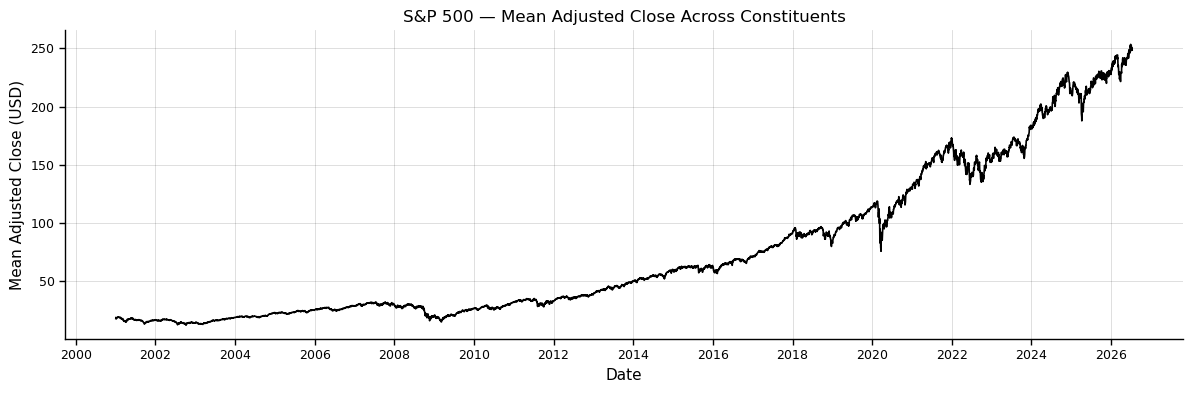

In [28]:
# Mean adjusted close across S&P 500 constituents, EPJ-styled.
mean_price = df_clean.mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mean_price.index, mean_price.values, color=NEUTRAL_COLOURS["primary"], linewidth=1.2)
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("S&P 500 — Mean Adjusted Close Across Constituents")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Adjusted Close (USD)")
fig.tight_layout()
plt.show()

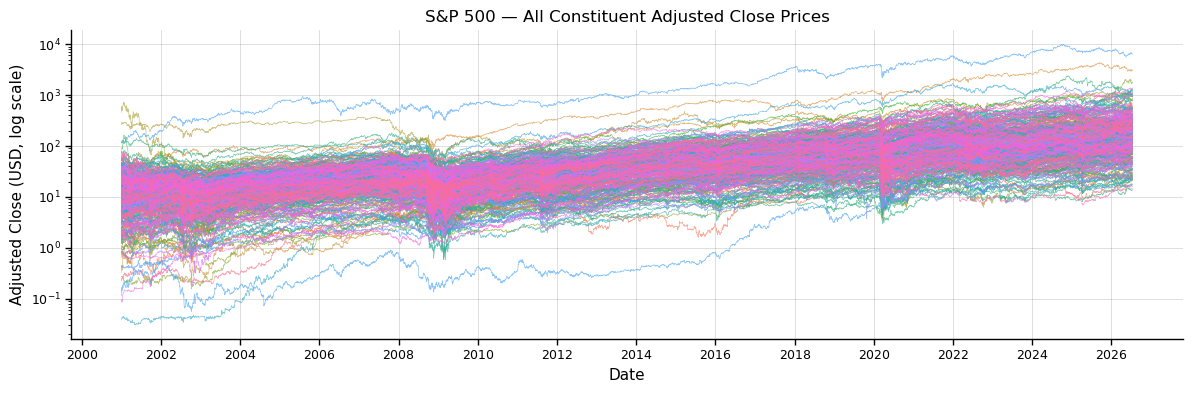

In [29]:
# All individual constituent prices overlaid, EPJ-styled (log scale: raw price levels span orders of magnitude across constituents), one colour per stock.
colours = sns.color_palette("husl", len(df_clean.columns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_prop_cycle(color=colours)
ax.plot(df_clean.index, df_clean.values, alpha=0.6, linewidth=0.5)
ax.set_yscale("log")
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("S&P 500 — All Constituent Adjusted Close Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Adjusted Close (USD, log scale)")
fig.tight_layout()
plt.show()

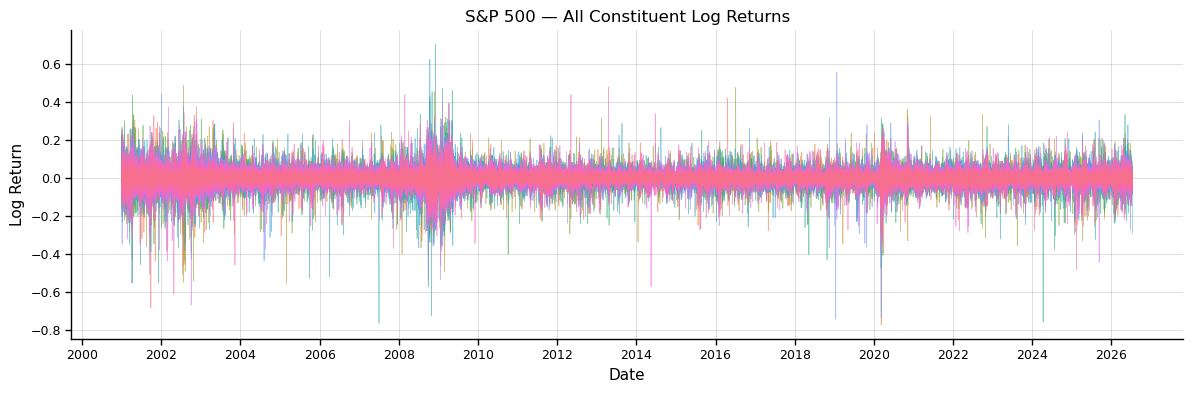

In [30]:
# All individual constituent log returns overlaid, EPJ-styled, one colour per stock.
log_returns = np.log(df_clean).diff()
colours = sns.color_palette("husl", len(log_returns.columns))

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_prop_cycle(color=colours)
ax.plot(log_returns.index, log_returns.values, alpha=0.6, linewidth=0.5)
style_axis(ax, grid=True)
format_date_axis(ax, interval_years=2)
ax.set_title("S&P 500 — All Constituent Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
fig.tight_layout()
plt.show()

In [31]:
# Raw price series of stocks removed by the prolonged trading halt screen.
df = df_raw.drop(columns=df_raw.columns[(df_raw <= 0).any()])
r = np.log(df).diff()
df = df.drop(columns=r.columns[(r.abs() > 0.8).any()])
df = df.dropna(how="any", axis=1)
r = np.log(df).diff()
flat = (r.abs() < 1e-12).mean(axis=1) > 0.98
df = df.loc[~flat]

HALT_STREAK_DAYS = 63
r = np.log(df).diff()
flat_by_stock = r.abs() < 1e-12
longest_halt = flat_by_stock.apply(lambda s: s.groupby((~s).cumsum()).cumsum().max())
halted_stocks = longest_halt[longest_halt >= HALT_STREAK_DAYS].index

if len(halted_stocks) > 0:
    colours = sns.color_palette("husl", len(halted_stocks))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_prop_cycle(color=colours)
    for stock in halted_stocks:
        ax.plot(df_raw.index, df_raw[stock], alpha=0.8, linewidth=0.8, label=stock)
    style_axis(ax, grid=True)
    format_date_axis(ax, interval_years=2)
    ax.set_title("S&P 500 — Raw Prices of Stocks Removed for Prolonged Trading Halts")
    ax.set_xlabel("Date")
    ax.set_ylabel("Adjusted Close (USD)")
    ax.legend(loc="best", fontsize=7)
    fig.tight_layout()
    plt.show()
else:
    print("No stocks removed for prolonged trading halts.")

No stocks removed for prolonged trading halts.


In [32]:
longest_halt.sort_values(ascending=False).head(10)

CS_TTWO     17
CST_MNST     7
ENE_TPL      5
CD_BKNG      5
FIN_ACGL     4
IND_CPRT     4
CD_DECK      4
HC_INCY      3
RE_EQIX      3
IT_TYL       3
dtype: int64